**Author**: Felipe Matheus  
**Pipeline**: Uncertainty-aware MBC — Annealing **with upstream grain-size propagation**

Proof-of-concept extending `mbc_annealing_uncertainty.ipynb` with a **chained**
surrogate: a (dummy) grain-size model predicts `grain_size_final` as a distribution,
and that distribution is **propagated** into the IACS surrogate via Monte Carlo
(copper_digital_twin_v4 §4.2) — so the IACS prediction's uncertainty correctly
includes the upstream grain-size uncertainty, instead of being overconfident from
plugging in only the grain-size mean.

Structure:
1. **Sections 1–3**: generate synthetic grain-size data, train a dummy
   uncertainty-aware grain-size surrogate, persist a real bundle.
2. **Sections 4–6**: load the IACS/UTS surrogates, build the grid, and propagate
   grain-size → IACS with K=200 Monte Carlo trajectories.
3. **Sections 7–9**: probabilistic feasibility, cost, selection, export — same as
   the base MBC notebook, now on the propagated distributions.

NOTE: the grain-size model here is **fake** (synthetic data, toy physics). It exists
only to test the propagation plumbing. Swapping in the real grain-size bundle is a
one-line path change in Section 5.

# 1. Setup

In [1]:
import os
import sys
import logging

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

module_path = os.path.abspath(os.path.join('../..'))
if module_path not in sys.path:
    sys.path.append(module_path)

from src.modeling.Modeling import Modeling
from src.modeling.MBCInference import MBCInference
from src.modeling.DummySurrogate import DummySurrogate
from src.metrics.ProbabilisticEvaluation import ProbabilisticEvaluation
from src.metrics.Evaluation import Evaluation
from src.DataLoader import LoaderHelper
from config.Variables import Variables

logging.basicConfig(level=logging.INFO,
                    format="%(asctime)s | %(levelname)s | %(name)s | %(message)s")

%load_ext autoreload
%autoreload 2

modl = Modeling()
evla = Evaluation()
load = LoaderHelper()
varv = Variables()
mbc = MBCInference(modl, load)
pev = ProbabilisticEvaluation()
dummy = DummySurrogate(modl, evla)

c:\Users\fmfoa\Projects\uncertainty-aware-predictors\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 2. Generate synthetic grain-size data

~100 rows from a toy heteroscedastic model: final grain size grows with thermal
budget (T, t) and initial grain size, shrinks with initial diameter, with noise that
widens at high temperature. Features: `initial_diameter`, `initial_grain_size`,
`temperature`, `time`. Target: `grain_size_final`.

In [2]:
df_gs = dummy.generate_data(n=100, seed=7)
print(df_gs[dummy.FEATURES + [dummy.TARGET]].describe().round(2).to_string())
df_gs.head()

2026-07-02 13:26:14,645 | INFO | src.modeling.DummySurrogate | Generated 100 synthetic grain-size rows.


       initial_diameter  initial_grain_size  temperature    time  grain_size_final
count            100.00              100.00       100.00  100.00            100.00
mean               1.41               50.21       619.78   76.98             43.79
std                0.35               18.01        58.09   26.53             12.61
min                0.83               21.95       523.75   30.47             19.08
25%                1.09               32.89       570.18   54.02             33.11
50%                1.48               50.02       623.14   77.12             45.68
75%                1.72               65.63       663.89   99.50             52.20
max                2.00               79.72       722.10  118.24             79.48


,initial_diameter,initial_grain_size,temperature,time,grain_size_final,is_essay
0,1.773905,58.473747,648.019093,117.043341,46.391447,False
1,1.589631,31.066739,702.442760,89.198466,46.421436,False
2,1.532901,65.569668,678.137138,68.539822,56.202648,False
3,1.029503,65.461440,568.041438,77.136610,52.201119,False
4,1.489274,63.277713,583.033257,108.552829,56.474975,False


# 3. Train the dummy grain-size surrogate

Runs the SAME two-model uncertainty-aware pipeline (Model A + Model B + NNLS weights
+ recalibration + OOD reference) as the annealing notebooks, and writes a real
`artifacts.pkl` bundle that `MBCInference.load_surrogate` reads unchanged.

In [3]:
GRAIN_SIZE_BUNDLE_DIR = os.path.join(
    varv.PATHS.models, "annealing_grain_size", "dummy_uncertainty_aware"
)

gs_result = dummy.train_and_persist(
    df_gs, bundle_dir=GRAIN_SIZE_BUNDLE_DIR,
    presets="medium_quality", time_limit_a=60, time_limit_b=30,
    y_min=0.0, y_max=None,   # grain size positive, no fixed ceiling
)
print("Grain-size dummy metrics (OOF):",
      {k: round(v, 3) for k, v in gs_result["metrics"].items() if k != "coverage"})
print("Recalibration c =", round(gs_result["artifacts"]["recalibration_c"], 4))

Verbosity: 2 (Standard Logging)
=================== System Info ===================
AutoGluon Version:  1.5.0
Python Version:     3.11.9
Operating System:   Windows
Platform Machine:   AMD64
Platform Version:   10.0.26200
CPU Count:          8
Pytorch Version:    2.9.1+cpu
CUDA Version:       CUDA is not available
Memory Avail:       12.48 GB / 31.57 GB (39.5%)
Disk Space Avail:   737.48 GB / 932.08 GB (79.1%)
Presets specified: ['medium_quality']
Using hyperparameters preset: hyperparameters='default'
Values in column 'weight_col' used as sample weights instead of predictive features. Evaluation metrics will ignore sample weights, specify weight_evaluation=True to instead report weighted metrics.
Beginning AutoGluon training ... Time limit = 60s
AutoGluon will save models to "c:\Users\fmfoa\Projects\uncertainty-aware-predictors\models\annealing_grain_size\dummy_uncertainty_aware\model_a"
Train Data Rows:    100
Train Data Columns: 5
Label Column:       grain_size_final
AutoGluon infer

Grain-size dummy metrics (OOF): {'rmse': 5.011, 'mae': 3.68, 'mape': 9.16, 'r2': 0.84}
Recalibration c = 2.5937


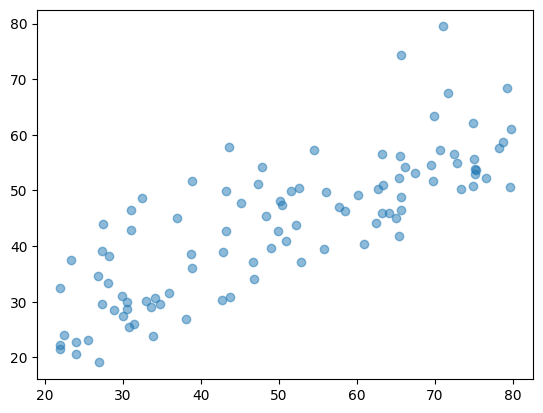

In [29]:
plt.plot(df_gs.initial_grain_size, df_gs.grain_size_final, "o", alpha=0.5)

In [30]:
gs_result

{'artifacts': {'target': 'grain_size_final',
  'features': ['initial_diameter',
   'initial_grain_size',
   'temperature',
   'time'],
  'base_model_names': ['LightGBMXT_BAG_L1',
   'LightGBM_BAG_L1',
   'RandomForestMSE_BAG_L1',
   'CatBoost_BAG_L1',
   'ExtraTreesMSE_BAG_L1',
   'NeuralNetFastAI_BAG_L1',
   'XGBoost_BAG_L1',
   'NeuralNetTorch_BAG_L1',
   'LightGBMLarge_BAG_L1'],
  'weights': array([4.44444373e-01, 3.60462615e-08, 3.25266853e-08, 0.00000000e+00,
         0.00000000e+00, 5.55555024e-02, 1.90609650e-08, 5.00000014e-01,
         2.32814370e-08]),
  'variance_floor': 1.5897879268296384,
  'recalibration_c': 2.5936848683198925,
  'use_weighted_variance': True,
  'calibration_after':    alpha  empirical_coverage   gap
  0   0.50                0.59  0.09
  1   0.80                0.82  0.02
  2   0.90                0.90  0.00
  3   0.95                0.95  0.00,
  'y_min': 0.0,
  'y_max': None,
  'ood_ref': {'features': ['initial_diameter',
    'initial_grain_size',
    

# 4. Configuration (IACS + grain-size chain)

The IACS surrogate consumes grain size as a feature. We point the IACS/UTS bundles
at their TAG folders and let `MBCInference.resolve_best_bundle` pick the best run
(by RMSE) from each `list_of_the_best.csv` — no hard-coded run hashes.

**IMPORTANT — feature-name bridge**: the grain-size *target* is `grain_size_final`,
but the IACS surrogate likely expects a feature named `grain_size` (the incoming
state). Set `DOWNSTREAM_GS_FEATURE` to whatever column name the IACS model was
trained on. If your IACS model does NOT use grain size at all, propagation is a
no-op — see the note in Section 6.

In [19]:
# ---- TAG folders (best run auto-picked by RMSE) ----
IACS_TAG_DIR = os.path.join(varv.PATHS.models, "annealing_iacs",
                            "experiments", "annealing-v1-best-quality")
UTS_TAG_DIR  = os.path.join(varv.PATHS.models, "annealing_uts",
                            "experiments", "annealing-uts-v1-best_quality")

# ---- Fixed material state (non-grid features) ----
# initial_grain_size + initial_diameter feed the grain-size model;
# purity/iacs/tensile_strength/initial_diameter feed IACS/UTS as before.
MATERIAL_PROPERTIES = {
    "purity": 99.95,
    "iacs": 98.47,
    "initial_diameter": 1.2,
    "initial_grain_size": 45.0,
    "tensile_strength": 250.0,
}

# Name of the IACS/UTS feature that receives the upstream grain-size target.
DOWNSTREAM_GS_FEATURE = "grain_size"

# ---- Grid ----
OPERATIONAL_LIMITS = {"temperature": [523, 723], "time": [30, 120]}
STEP = {"temperature": 10, "time": 5}

# ---- Probabilistic acceptance ----
MIN_SETPOINTS = {"iacs": 99.5, "tensile_strength": 210.0}
DELTA = 0.10
KAPPA = 1.645
K_SAMPLES = 200

# 5. Load surrogates (grain-size dummy + IACS + UTS best runs)

In [5]:
# grain-size: explicit dummy bundle we just trained
gs_bundle = mbc.load_surrogate(GRAIN_SIZE_BUNDLE_DIR)

# iacs + uts: best run auto-resolved from each tag folder
down_bundles = mbc.load_surrogates_best(
    {"iacs": IACS_TAG_DIR, "uts": UTS_TAG_DIR}, metric="rmse",
)

print("grain_size features:", gs_bundle.features)
for k, b in down_bundles.items():
    print(f"{k} features:", b.features,
          "| uses grain size:", DOWNSTREAM_GS_FEATURE in b.features)

2026-07-02 13:27:42,120 | INFO | src.modeling.MBCInference | Loaded surrogate 'grain_size' (features=['initial_diameter', 'initial_grain_size', 'temperature', 'time']) from ..\..\models\annealing_grain_size\dummy_uncertainty_aware
2026-07-02 13:27:42,134 | INFO | src.modeling.MBCInference | Resolved best bundle by rmse: annealing-v1-best-quality__time_limit_a=1500__num_bag_folds_a=20__weight_on_essay_rows=1.0__d91e7f29
2026-07-02 13:27:42,142 | INFO | src.modeling.MBCInference | Resolved best bundle by rmse: annealing-uts-v1-best_quality__time_limit_a=900__num_bag_folds_a=10__df848c54
2026-07-02 13:27:42,652 | INFO | src.modeling.MBCInference | Loaded surrogate 'iacs' (features=['purity', 'iacs', 'temperature', 'time']) from ..\..\models\annealing_iacs\experiments\annealing-v1-best-quality\annealing-v1-best-quality__time_limit_a=1500__num_bag_folds_a=20__weight_on_essay_rows=1.0__d91e7f29
2026-07-02 13:27:43,137 | INFO | src.modeling.MBCInference | Loaded surrogate 'tensile_strength' (

grain_size features: ['initial_diameter', 'initial_grain_size', 'temperature', 'time']
iacs features: ['purity', 'iacs', 'temperature', 'time'] | uses grain size: False
uts features: ['purity', 'initial_diameter', 'tensile_strength', 'temperature', 'time'] | uses grain size: False


# 6. Build grid + propagate grain-size → IACS

Monte Carlo (K=200): per grid cell, draw K grain-size samples from the dummy
surrogate's truncated predictive distribution, run IACS on each, and aggregate to
an IACS mean + total variance that now contains the propagated grain-size variance
(§4.2). The extra column `iacs_sigma2_propagated` is exactly the upstream
contribution — compare it to `iacs_sigma2_epist`/`iacs_sigma2_aleat` to see how much
the grain-size uncertainty widened IACS.

If `grain_size` is NOT an IACS feature, skip propagation and predict IACS directly
(the `if` below handles both).

In [6]:
param_grid = mbc.build_param_grid(OPERATIONAL_LIMITS, STEP)
df_grid = mbc.build_state_grid_df(MATERIAL_PROPERTIES, param_grid)
print(f"Grid: {len(df_grid)} cells")

iacs_bundle = down_bundles["iacs"]
if DOWNSTREAM_GS_FEATURE in iacs_bundle.features:
    df_prop = mbc.propagate_upstream_to_downstream(
        upstream=gs_bundle, downstream=iacs_bundle, df_grid=df_grid,
        downstream_feature=DOWNSTREAM_GS_FEATURE, k_samples=K_SAMPLES, seed=0,
    )
    print("Propagated grain_size -> iacs.")
else:
    print(f"IACS does not use '{DOWNSTREAM_GS_FEATURE}'; predicting IACS directly "
          "(no propagation).")
    df_prop = mbc.predict_surrogate(iacs_bundle, df_grid)

df_prop.head()

Grid: 399 cells
IACS does not use 'grain_size'; predicting IACS directly (no propagation).


,purity,iacs,initial_diameter,initial_grain_size,tensile_strength,temperature,time,iacs_mu,iacs_sigma,iacs_sigma2_epist,iacs_sigma2_aleat,iacs_ood_multiplier
0,99.95,98.47,1.2,45.0,250.0,523,30,100.122591,1.305880,0.023167,1.411706,1.0
1,99.95,98.47,1.2,45.0,250.0,523,35,99.355366,1.383696,0.199268,1.411706,1.0
2,99.95,98.47,1.2,45.0,250.0,523,40,99.350637,1.383696,0.199269,1.411706,1.0
3,99.95,98.47,1.2,45.0,250.0,523,45,99.345847,1.383721,0.199327,1.411706,1.0
4,99.95,98.47,1.2,45.0,250.0,523,50,99.463805,1.468305,0.402303,1.411706,1.0


In [7]:
# Quantify how much the upstream uncertainty mattered
if "iacs_sigma2_propagated" in df_prop.columns:
    sig_prop = np.sqrt(df_prop["iacs_sigma2_propagated"]).mean()
    sig_epist = np.sqrt(df_prop["iacs_sigma2_epist"]).mean()
    sig_aleat = np.sqrt(df_prop["iacs_sigma2_aleat"]).mean()
    print(f"Mean IACS sigma contributions:")
    print(f"  propagated (grain-size):  {sig_prop:.3f}")
    print(f"  downstream epistemic:     {sig_epist:.3f}")
    print(f"  downstream aleatoric:     {sig_aleat:.3f}")
    print(f"  -> total sigma:           {df_prop['iacs_sigma'].mean():.3f}")

## 6.1 UTS prediction (no grain-size dependence assumed)

UTS is predicted directly on the grid. If UTS also consumed grain size, you would
propagate it the same way; here it is treated as independent for simplicity.

In [15]:
uts_bundle = down_bundles["uts"]
uts_preds = mbc.predict_surrogate(uts_bundle, df_grid)
# merge UTS distribution columns into df_prop
uts_cols = [c for c in uts_preds.columns if c.startswith("tensile_strength_")]
for c in uts_cols:
    df_prop[c] = uts_preds[c].to_numpy()
df_prop[["temperature", "time", "iacs_mu", "iacs_sigma",
         "tensile_strength_mu", "tensile_strength_sigma"]].head()

,temperature,time,iacs_mu,iacs_sigma,tensile_strength_mu,tensile_strength_sigma
0,523,30,100.122591,1.305880,232.148544,18.802371
1,523,35,99.355366,1.383696,231.148034,19.318132
2,523,40,99.350637,1.383696,231.124011,19.330748
3,523,45,99.345847,1.383721,231.100029,19.343348
4,523,50,99.463805,1.468305,232.516513,20.206089


# 7. Probabilistic feasibility

In [18]:
MIN_SETPOINTS

{'iacs': 99.5, 'uts': 210.0}

In [21]:
surrogate_bounds = {
    "iacs": (iacs_bundle.artifacts.get("y_min"), iacs_bundle.artifacts.get("y_max")),
    "tensile_strength":  (uts_bundle.artifacts.get("y_min"),  uts_bundle.artifacts.get("y_max")),
}
df_prob = pev.add_success_probabilities(
    df_prop, MIN_SETPOINTS, surrogate_bounds=surrogate_bounds, modl=modl,
)
df_feasible = pev.apply_probabilistic_setpoints(df_prob, delta=DELTA)
print(f"Feasible cells (Pr >= {1-DELTA:.2f}): {len(df_feasible)} / {len(df_prob)}")
df_prob[["temperature", "time", "iacs_mu", "iacs_sigma", "pr_success_iacs",
         "tensile_strength_mu", "pr_success_tensile_strength", "pr_success_all"]].head(10)

2026-07-02 13:35:00,029 | INFO | src.metrics.ProbabilisticEvaluation | Probabilistic setpoints (delta=0.10 -> Pr>=0.90): kept 0 / 399 cells.
2026-07-02 13:35:00,029 | WARNING | src.metrics.ProbabilisticEvaluation | No cell met Pr >= 0.90. Max Pr on grid was 0.605. Relax delta, gate on a single target, or revisit setpoints/model.


Feasible cells (Pr >= 0.90): 0 / 399


,temperature,time,iacs_mu,iacs_sigma,pr_success_iacs,tensile_strength_mu,pr_success_tensile_strength,pr_success_all
0,523,30,100.122591,1.305880,0.683233,232.148544,0.880595,0.601652
1,523,35,99.355366,1.383696,0.458375,231.148034,0.863181,0.395661
2,523,40,99.350637,1.383696,0.457020,231.124011,0.862752,0.394295
3,523,45,99.345847,1.383721,0.455648,231.100029,0.862323,0.392916
4,523,50,99.463805,1.468305,0.490167,232.516513,0.867434,0.425187
5,523,55,99.459653,1.468945,0.489044,232.492959,0.867027,0.424014
6,523,60,99.238353,1.555261,0.433200,231.218039,0.838674,0.363313
7,523,65,98.231932,2.102752,0.273237,229.381404,0.800740,0.218792
8,523,70,98.208438,2.114715,0.270683,229.362960,0.800360,0.216644
9,523,75,98.184306,2.126851,0.268086,229.344789,0.799984,0.214465


## 7.1 Effect of propagation on feasibility

Re-run feasibility WITHOUT propagation (IACS using only the grain-size mean) to see
how propagation changes the safe region — the overconfident version typically marks
more cells "safe" than they really are.

In [23]:
# Naive: IACS predicted with grain_size fixed at its mean (no upstream variance)
df_naive = df_grid.copy()
if DOWNSTREAM_GS_FEATURE in iacs_bundle.features:
    gs_mu = mbc.predict_surrogate(gs_bundle, df_grid)[f"{gs_bundle.short_name}_mu"]
    df_naive[DOWNSTREAM_GS_FEATURE] = gs_mu.to_numpy()
df_naive_pred = mbc.predict_surrogate(iacs_bundle, df_naive)
df_naive_pred["tensile_strength_mu"] = uts_preds["tensile_strength_mu"].to_numpy()
df_naive_pred["tensile_strength_sigma"] = uts_preds["tensile_strength_sigma"].to_numpy()
df_naive_prob = pev.add_success_probabilities(
    df_naive_pred, MIN_SETPOINTS, surrogate_bounds=surrogate_bounds, modl=modl,
)
n_naive = (df_naive_prob["pr_success_all"] >= 1 - DELTA).sum()
n_prop = (df_prob["pr_success_all"] >= 1 - DELTA).sum()
print(f"Cells marked feasible:  naive(mean-only)={n_naive}  propagated={n_prop}")
print("If naive > propagated, the mean-only pipeline was overconfident "
      "(claimed safety it could not back up).")

Cells marked feasible:  naive(mean-only)=0  propagated=0
If naive > propagated, the mean-only pipeline was overconfident (claimed safety it could not back up).


# 8. Cost + selection

In [24]:
df_cost = pev.add_cost_function(
    pev.add_cost_function_physics(df_feasible),
    operational_limits=OPERATIONAL_LIMITS,
)
df_cost = pev.add_risk_adjusted_value(df_cost, "iacs", kappa=KAPPA)

SELECTION_SPEC_LOW = {
    "lowest_time": "time", "lowest_temperature": "temperature",
    "lowest_cost": "cost", "lowest_cost_phys": "cost_phys",
}
SELECTION_SPEC_HIGH = {
    "safest_iacs": "pr_success_iacs", "safest_combined": "pr_success_all",
}
selected = {
    **pev.select_lowest_by_features(df_cost, SELECTION_SPEC_LOW),
    **pev.select_highest_by_features(df_cost, SELECTION_SPEC_HIGH),
}
for label, sub in selected.items():
    if len(sub):
        r = sub.iloc[0]
        print(f"{label:20s} -> T={r['temperature']:.0f}K t={r['time']:.0f}min "
              f"| iacs={r['iacs_mu']:.2f}(+/-{r['iacs_sigma']:.2f}) "
              f"| Pr_all={r['pr_success_all']:.3f}")

# 9. Export

In [25]:
from pathlib import Path

IDENTIFIER = "grain_size_chain_pilot"
output_dir = Path(varv.PATHS.data_enriched) / "mbc_annealing_chain"
output_dir.mkdir(parents=True, exist_ok=True)

rows = []
for label, sub in selected.items():
    if len(sub):
        r = sub.iloc[0].copy(); r["selection"] = label; rows.append(r)
export_df = pd.DataFrame(rows)
keep = (["selection", "temperature", "time"]
        + [c for c in export_df.columns
           if c.endswith(("_mu", "_sigma")) or c.startswith("pr_success")
           or c in ("cost", "cost_phys", "iacs_lcb")])
export_df = export_df[[c for c in keep if c in export_df.columns]]
export_df["temperature_C"] = export_df["temperature"] - 273

out_path = output_dir / f"mbc_ann_chain_{IDENTIFIER}.csv"
export_df.to_csv(out_path, index=False)
print(f"Saved {len(export_df)} selections to {out_path}")
export_df

KeyError: 'temperature'